In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import timm
import torch.nn.functional as F
from torch.cuda.amp import GradScaler, autocast

from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


parameter

In [3]:
train_dir = "../Data_v2/train"
test_dir = "../Data_v2/test"
val_dir = "../Data_v2/validation"

In [4]:
class Imagedataset(Dataset):
    def __init__ (self, data_dir, transform = None):
        self.data = ImageFolder(data_dir, transform= transform)
    def __len__ (self):
        return len(self.data)
        
    def __getitem__(self, idx):
        return self.data[idx]
    
    @property
    def classes(self):
        return self.data.classes

In [5]:
Id_to_class = {v : k for k, v in ImageFolder(train_dir).class_to_idx.items()}

print(Id_to_class)

{0: 'Fake', 1: 'Real'}


In [6]:
tran = transforms.Compose([
    transforms.Resize((500, 500)),
    transforms.ToTensor(),
]
)
 
train_dataset = Imagedataset(train_dir, tran)
test_dataset = Imagedataset(test_dir, tran)
val_dataset = Imagedataset(val_dir, tran)

In [85]:
num_epochs = 15
batch_size = 65
learning_rate = 0.001

dataloader

In [9]:
train_Loader = DataLoader(train_dataset, batch_size, shuffle=True)
test_Loader = DataLoader(test_dataset, batch_size, shuffle=False)
val_Loader = DataLoader(val_dataset, batch_size,  shuffle=False)

## CNN module

In [10]:
print(torch.__file__)

c:\Users\reyhan\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\__init__.py


In [47]:
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.con1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.con2 = nn.Conv2d(6, 16, 5)
        self.dropout = nn.Dropout(p=0.4)
        self.fc1 = nn.Linear(16*122*122, 240)
        self.fc2 = nn.Linear(240, 120)
        self.fc3 = nn.Linear(120, 84)
        self.fc4 = nn.Linear(84, 16)
        self.fc5 = nn.Linear(16, 8)
        self.fc6 = nn.Linear(8, 2)
        
    def forward(self, x):
        x = self.pool(F.relu(self.con1(x)))
        x = self.pool(F.relu(self.con2(x)))
        x = x.view(-1, 16*122*122)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = F.relu(self.fc3(x))
        x = self.dropout(x)
        x = F.relu(self.fc4(x))
        x = self.dropout(x)
        x = F.relu(self.fc5(x))
        x = self.dropout(x)
        x = self.fc6(x)
        return x


In [12]:
train_losses = []
val_losses = []

train_losses.append(0.6926)
val_losses.append(0.6921)

train_losses.append(0.6916)
val_losses.append(0.6909)

train_losses.append(0.6895)
val_losses.append(0.6879)

train_losses.append(0.6847)
val_losses.append(0.6811)

train_losses.append(0.6717)
val_losses.append(0.6578)

train_losses.append(0.6263)
val_losses.append(0.5883)

train_losses.append(0.5489)
val_losses.append(0.5388)

train_losses.append(0.5160)
val_losses.append(0.4989)

train_losses.append(0.4968)
val_losses.append(0.4875)

train_losses.append(0.4801)
val_losses.append(0.4766)

In [40]:
import pickle

def save_list(float_list, filename):
    with open(filename, 'wb') as file:
        pickle.dump(float_list, file)
    print(f"List saved to {filename}")

def load_list(filename):
    try:
        with open(filename, 'rb') as file:
            float_list = pickle.load(file)
        print(f"List loaded from {filename}")
        return float_list
    except FileNotFoundError:
        print(f"No file found at {filename}")
        return []

In [41]:
save_list(train_losses, '../train_losses.lst')

type2 = load_list('../train_losses.lst')

print(train_losses)
print(type2)

List saved to C:/Users/reyhan/Desktop/Tasks/Project AI image detection/train_losses.lst
List loaded from C:/Users/reyhan/Desktop/Tasks/Project AI image detection/train_losses.lst
[0.6926, 0.6916, 0.6895, 0.6847, 0.6717, 0.6263, 0.5489, 0.516, 0.49680598924826536, 0.4801425997398185, 0.4624788704846132, 0.44730265123741847, 0.4353731557130637, 0.42453247879485045, 0.41514467467091326, 0.4063674453124664, 0.3982548595484722, 0.3897995631214032, 0.3826265474042337, 0.37489062095192716, 0.36689218405860097, 0.3588730627952265, 0.3496156890410135, 0.3433982378272718, 0.33392775330973773, 0.3263950305389051, 0.31760666926541653]
[0.6926, 0.6916, 0.6895, 0.6847, 0.6717, 0.6263, 0.5489, 0.516, 0.49680598924826536, 0.4801425997398185, 0.4624788704846132, 0.44730265123741847, 0.4353731557130637, 0.42453247879485045, 0.41514467467091326, 0.4063674453124664, 0.3982548595484722, 0.3897995631214032, 0.3826265474042337, 0.37489062095192716, 0.36689218405860097, 0.3588730627952265, 0.3496156890410135,

In [83]:
best_val_acc = 88.08131982333073

In [86]:
model = ConvNet().to(device)
model.load_state_dict(torch.load('../Model/cnnV2_64.pth'))
model.to(device)


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
training_rate = []

n_total_steps = len(train_Loader)

print('start training')
print(f'Epoc: {num_epochs}')

scaler = torch.amp.GradScaler()

for epoch in range(num_epochs):
    model.train()
    loop = tqdm(train_Loader, leave=False)
    train_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loop:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        # Enable autocasting for mixed precision
        with torch.amp.autocast(device_type='cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)

        # Backward pass with scaler
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item() * labels.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    avg_train_loss = train_loss / len(train_Loader.dataset)
    train_acc = 100.0 * correct / total

    # === Validation phase ===
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        val_loop = tqdm(val_Loader, leave=False)

        for images, labels in val_loop:
            images = images.to(device)
            labels = labels.to(device)

            with torch.amp.autocast(device_type='cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * labels.size(0)

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_Loader.dataset)
    val_acc = 100.0 * val_correct / val_total

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), '../Model/best_model.pth')

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    save_list(train_losses, '../train_losses.lst')
    save_list(val_losses, '../val_losses.lst')

    print(f'Epoch [{epoch+1}/{num_epochs}] '
          f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}% '
          f'| Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%')

    # Save model per epoch
    PATH = f'../Model/cnnV2_{epoch + 65}.pth'
    torch.save(model.state_dict(), PATH)

print('Finished Training')
#PATH = '../cnn no 2.pth'
#torch.save(model.state_dict(), PATH)

with torch.no_grad():
    n_correct = 0
    n_samples = 0
    n_class_correct = [0 for i in range(2)]
    n_class_samples = [0 for i in range(2)]
    for images, labels in test_Loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        # max returns (value ,index)
        _, predicted = torch.max(outputs, 1)
        n_samples += labels.size(0)
        n_correct += (predicted == labels).sum().item()
        
        for i in range(labels.size(0)):
            label = labels[i]
            pred = predicted[i]
            if (label == pred):
                n_class_correct[label] += 1
            n_class_samples[label] += 1

    acc = 100.0 * n_correct / n_samples
    print(f'Accuracy of the network: {acc} %')

    acc = 100.0 * n_class_correct[0] / n_class_samples[0]
    print(f'Accuracy of Fake: {acc} %')

    acc = 100.0 * n_class_correct[1] / n_class_samples[1]
    print(f'Accuracy of Real: {acc} %')

start training
Epoc: 15


  0%|          | 0/1658 [00:00<?, ?it/s]

c:\Users\reyhan\AppData\Local\Programs\Python\Python312\Lib\site-packages\PIL\Image.py:1054: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  0%|          | 0/474 [00:00<?, ?it/s]

List saved to C:/Users/reyhan/Desktop/Tasks/Project AI image detection/train_losses.lst
List saved to C:/Users/reyhan/Desktop/Tasks/Project AI image detection/val_losses.lst
Epoch [1/15] Train Loss: 0.1793, Train Acc: 93.97% | Val Loss: 0.3912, Val Acc: 87.85%


...

  0%|          | 0/1658 [00:00<?, ?it/s]

  0%|          | 0/474 [00:00<?, ?it/s]

List saved to C:/Users/reyhan/Desktop/Tasks/Project AI image detection/train_losses.lst
List saved to C:/Users/reyhan/Desktop/Tasks/Project AI image detection/val_losses.lst
Epoch [13/15] Train Loss: 0.1095, Train Acc: 96.31% | Val Loss: 0.4915, Val Acc: 87.88%


  0%|          | 0/1658 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [89]:
model = ConvNet().to(device)
model.load_state_dict(torch.load('../Model/best_model.pth'))
model.to(device)

with torch.no_grad():
    n_correct = 0
    n_samples = 0
    n_class_correct = [0 for i in range(2)]
    n_class_samples = [0 for i in range(2)]
    for images, labels in test_Loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        # max returns (value ,index)
        _, predicted = torch.max(outputs, 1)
        n_samples += labels.size(0)
        n_correct += (predicted == labels).sum().item()
        
        for i in range(labels.size(0)):
            label = labels[i]
            pred = predicted[i]
            if (label == pred):
                n_class_correct[label] += 1
            n_class_samples[label] += 1

    acc = 100.0 * n_correct / n_samples
    print(f'Accuracy of the network: {acc} %')

    acc = 100.0 * n_class_correct[0] / n_class_samples[0]
    print(f'Accuracy of Fake: {acc} %')

    acc = 100.0 * n_class_correct[1] / n_class_samples[1]
    print(f'Accuracy of Real: {acc} %')

Accuracy of the network: 84.9821370574862 %
Accuracy of Fake: 82.40427194581922 %
Accuracy of Real: 87.54697421277699 %


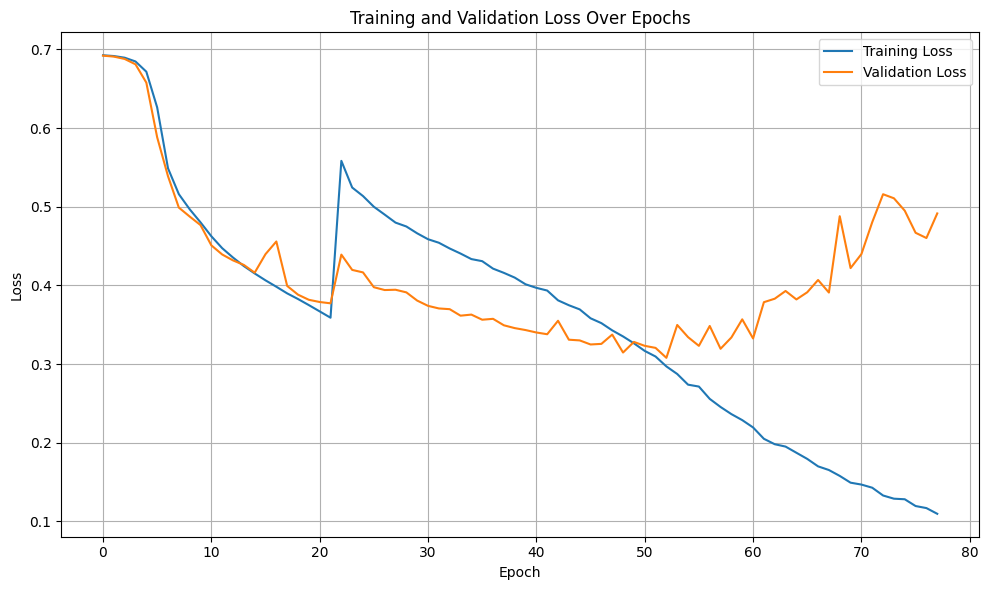

In [87]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## VIsualize result

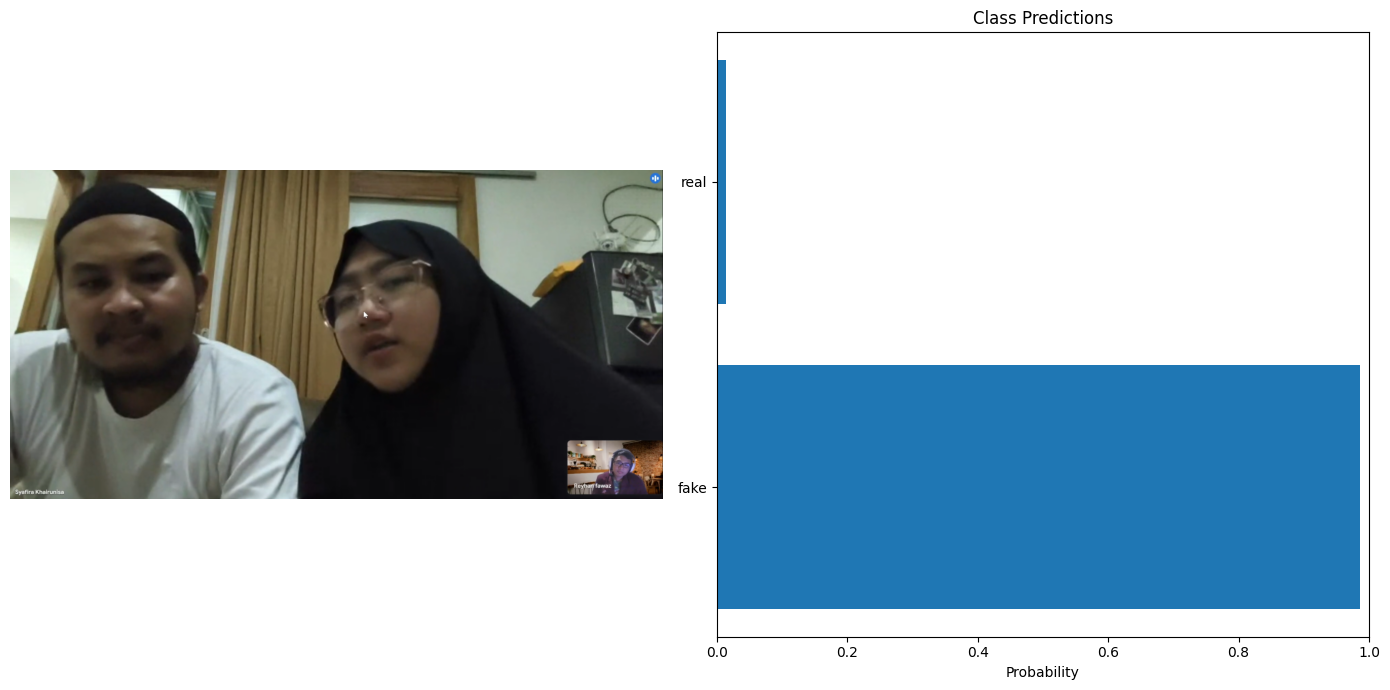

In [103]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

model = ConvNet().to(device)
model.load_state_dict(torch.load('../model/cnnV2_77.pth'))
model.to(device)

# Load and preprocess the image
def preprocess_image(image_path, transform):
    image = Image.open(image_path).convert("RGB")
    return image, transform(image).unsqueeze(0)

# Predict using the model
def predict(model, image_tensor, device):
    model.eval()
    with torch.no_grad():
        image_tensor = image_tensor.to(device)
        outputs = model(image_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
    return probabilities.cpu().numpy().flatten()

# Visualization
def visualize_predictions(original_image, probabilities, class_names):
    fig, axarr = plt.subplots(1, 2, figsize=(14, 7))
    
    # Display image
    axarr[0].imshow(original_image)
    axarr[0].axis("off")
    
    # Display predictions
    axarr[1].barh(class_names, probabilities)
    axarr[1].set_xlabel("Probability")
    axarr[1].set_title("Class Predictions")
    axarr[1].set_xlim(0, 1)

    plt.tight_layout()
    plt.show()

# Example usage
test_image = "../docs/samples/Screenshot 2025-02-27 203945.png"
transform = transforms.Compose([
    transforms.Resize((500, 500)),
    transforms.ToTensor()
])

original_image, image_tensor = preprocess_image(test_image, transform)
probabilities = predict(model, image_tensor, device)

# Assuming dataset.classes gives the class names
class_names = ['fake', 'real']
visualize_predictions(original_image, probabilities, class_names)
